# Lineage — tracing SARS-CoV-2 samples to their region of origin

As SARS-CoV-2 spread around the world in 2020, it steadily accumulated mutations. Because outbreaks in
different parts of the world grew from different introductions, the set of mutations a sample carries acts
as a geographic fingerprint. This notebook asks a simple question:

> **Can we predict which region of the world a SARS-CoV-2 sample came from, using only its genome?**

Three things come out of it:

1. A leakage-controlled classifier that assigns held-out genomes to **Asia / North America / Oceania
   with ~80% accuracy** (vs. a 33% random baseline), using an interpretable linear model.
2. A readout of *which* mutations carry the geographic signal, mapped onto the SARS-CoV-2 gene map.
3. A demonstration of how the *same* model on the *same* data reports **94%** if you featurize
   carelessly — and why that number is a lie. Getting this part right is most of the project.

**Data:** 1,538 complete SARS-CoV-2 genomes from the
[NCBI Virus database](https://www.ncbi.nlm.nih.gov/labs/virus/vssi/#/) (an early-pandemic 2020 snapshot),
aligned to the Wuhan-Hu-1 reference genome ([NC_045512](https://www.ncbi.nlm.nih.gov/nuccore/NC_045512)),
29,903 positions each. The aligned FASTA ships with this repo (`data/`, 406 KB gzipped).

## Setup

In [1]:
import gzip
import urllib.request
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import cross_val_score, train_test_split

SEED = 42

DATA_PATH = Path("data/cov2_sequences.fasta.gz")
DATA_URL = "https://github.com/jomeiroot/lineage/raw/main/data/cov2_sequences.fasta.gz"

if not DATA_PATH.exists():  # e.g. when running in Colab
    DATA_PATH.parent.mkdir(exist_ok=True)
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

## Loading the genomes

A FASTA file is just a header line (`>accession | description | country`) followed by sequence lines,
so we can parse it in a few lines without pulling in a bioinformatics library. The first record is the
Wuhan-Hu-1 reference; every other genome is aligned against it, so position *i* means the same thing
in every row.

One hygiene step happens right here: **deduplication**. The same outbreak clusters were sequenced
many times over in early 2020, so the file contains byte-identical genomes. If copies of the same
genome land on both sides of a train/test split, the model gets graded on samples it has literally
seen — leakage, before we've even built a feature.

In [2]:
def read_fasta(path):
    headers, seqs, chunks = [], [], []
    with gzip.open(path, "rt") as f:
        for line in f:
            if line.startswith(">"):
                if chunks:
                    seqs.append("".join(chunks))
                    chunks = []
                headers.append(line[1:].strip())
            else:
                chunks.append(line.strip())
    seqs.append("".join(chunks))
    return headers, seqs


headers, seqs = read_fasta(DATA_PATH)
reference = np.array(list(seqs[0]), dtype="U1")  # Wuhan-Hu-1 (NC_045512)

_, first_seen = np.unique(np.array(seqs), return_index=True)
keep = np.sort(first_seen)

genomes = np.array([list(seqs[i]) for i in keep], dtype="U1")
countries = [headers[i].split("|")[-1].strip() if "|" in headers[i] else "" for i in keep]

print(f"{len(seqs)} genomes -> {genomes.shape[0]} unique x {genomes.shape[1]} aligned positions")
Counter(countries).most_common(10)

1538 genomes -> 1385 unique x 29903 aligned positions


[('USA', 1092),
 ('Australia', 154),
 ('China', 47),
 ('Taiwan', 20),
 ('India', 19),
 ('Thailand', 18),
 ('Hong Kong', 15),
 ('Kazakhstan', 4),
 ('Sri Lanka', 4),
 ('Viet Nam', 2)]

## How much has the virus mutated?

Comparing every genome against the reference, position by position:

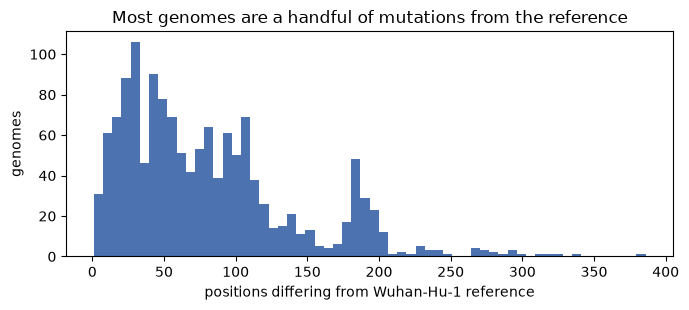

In [3]:
diffs_from_ref = (genomes != reference).sum(axis=1)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(diffs_from_ref[1:], bins=60, color="#4C72B0")
ax.set_xlabel("positions differing from Wuhan-Hu-1 reference")
ax.set_ylabel("genomes")
ax.set_title("Most genomes are a handful of mutations from the reference")
plt.tight_layout()

The long right tail is mostly *not* biology: those genomes contain runs of `N` (unresolved bases) or `-`
(alignment gaps) from incomplete sequencing. We can confirm that the outliers are explained by
ambiguous bases rather than true substitutions:

In [4]:
is_acgt = np.isin(genomes, list("ATGC"))
ambiguous = (~is_acgt).sum(axis=1)

print("correlation between distance-from-reference and ambiguous-base count:",
      f"{np.corrcoef(diffs_from_ref[1:], ambiguous[1:])[0, 1]:.3f}")

correlation between distance-from-reference and ambiguous-base count: 0.999


A correlation of ~1.0: essentially *all* of the variance in "distance from reference" is sequencing
quality, not evolution. This number is the reason the featurization below only counts clean
`A/T/G/C` substitutions and treats `N`/`-` as missing data — and it foreshadows the trap at the
end of the notebook.

## Labels: country → region

Country labels come straight from the FASTA headers. Some countries have only a couple of samples,
so the classification target is the *region*: **Asia**, **North America**, or **Oceania**
(the three regions with enough data in this snapshot).

In [5]:
REGION = {
    "USA": "North America",
    "Australia": "Oceania",
    "China": "Asia", "Taiwan": "Asia", "India": "Asia", "Hong Kong": "Asia",
    "Thailand": "Asia", "Kazakhstan": "Asia", "Sri Lanka": "Asia",
    "South Korea": "Asia", "Viet Nam": "Asia", "Israel": "Asia",
    "Iran": "Asia", "Pakistan": "Asia", "Nepal": "Asia", "Japan": "Asia",
}
regions = pd.Series([REGION.get(c) for c in countries], name="region")
regions.value_counts(dropna=False)

region
North America    1092
Oceania           154
Asia              138
NaN                 1
Name: count, dtype: int64

## Features: one column per recurrent mutation

Each feature is a specific substitution in standard virology notation — `A23403G` means
"position 23403 changed from `A` (reference) to `G`". Two deliberate restrictions:

- **Real bases only.** `N` and `-` are sequencing artifacts, not mutations (see above).
- **Recurrent only** (seen in ≥ 3 genomes). A substitution observed once is as likely to be a
  sequencing error as a real variant, and a feature that fires for a single training genome is
  just a memorization handle.

In [6]:
MIN_COUNT = 3

substituted = (genomes != reference) & is_acgt
features = {}
for pos in np.flatnonzero(substituted.any(axis=0)):
    column = genomes[:, pos]
    for base in "ATGC":
        if base == reference[pos]:
            continue
        hits = substituted[:, pos] & (column == base)
        if hits.sum() >= MIN_COUNT:
            features[f"{reference[pos]}{pos + 1}{base}"] = hits.astype(np.int8)

X_all = pd.DataFrame(features)
print(f"{X_all.shape[1]} recurrent substitutions across {X_all.shape[0]} genomes")

253 recurrent substitutions across 1385 genomes


## Balancing the classes

North America has ~8× more samples than Asia, and an unbalanced model gets rewarded for just
guessing the majority class — so we downsample every region to the size of the smallest one.

In [7]:
data = X_all.assign(region=regions.values).dropna(subset=["region"])
per_class = data["region"].value_counts().min()
balanced = data.groupby("region").sample(n=per_class, random_state=SEED)

X = balanced.drop(columns="region")
y = balanced["region"]
y.value_counts()

region
Asia             138
North America    138
Oceania          138
Name: count, dtype: int64

## Training

A multinomial logistic regression: linear, fast, and — crucially for the analysis afterwards —
every feature gets a per-region coefficient we can interpret. The only hyperparameter that matters
here is the regularization strength `C`, chosen by cross-validation **on the training split only**
(tuning on data you'll report results for is its own little leakage).

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

candidates = {}
for C in (0.1, 1.0, 10.0, 30.0):
    scores = cross_val_score(LogisticRegression(max_iter=5000, C=C), X_train, y_train, cv=5)
    candidates[C] = scores.mean()
    print(f"C={C:<5} train-CV accuracy: {scores.mean():.1%} ± {scores.std():.1%}")

best_C = max(candidates, key=candidates.get)
print(f"\nselected C={best_C}")

C=0.1   train-CV accuracy: 74.9% ± 6.4%
C=1.0   train-CV accuracy: 77.6% ± 6.0%
C=10.0  train-CV accuracy: 77.0% ± 4.4%


C=30.0  train-CV accuracy: 79.2% ± 3.1%

selected C=30.0


In [9]:
model = LogisticRegression(max_iter=5000, C=best_C)
model.fit(X_train, y_train)

print(f"held-out test accuracy: {model.score(X_test, y_test):.1%}  (random baseline: 33.3%)\n")
print(classification_report(y_test, model.predict(X_test)))

held-out test accuracy: 79.5%  (random baseline: 33.3%)

               precision    recall  f1-score   support

         Asia       0.88      0.81      0.85        27
North America       0.81      0.75      0.78        28
      Oceania       0.72      0.82      0.77        28

     accuracy                           0.80        83
    macro avg       0.80      0.80      0.80        83
 weighted avg       0.80      0.80      0.80        83



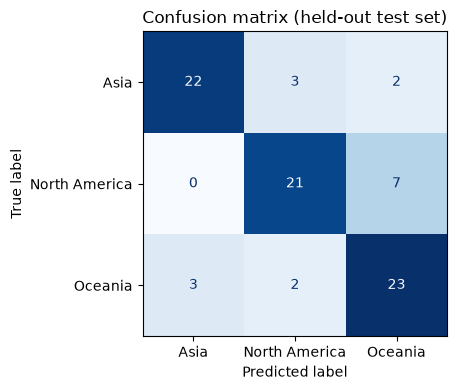

In [10]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion matrix (held-out test set)")
plt.tight_layout()

A single 83-genome test set is small, so as a stability check, 5-fold cross-validation over the
whole balanced dataset with the chosen `C`:

In [11]:
cv_scores = cross_val_score(LogisticRegression(max_iter=5000, C=best_C), X, y, cv=5)
print(f"5-fold CV accuracy: {cv_scores.mean():.1%} ± {cv_scores.std():.1%}")
print("per fold:", np.round(cv_scores, 3))

5-fold CV accuracy: 79.5% ± 3.6%
per fold: [0.807 0.843 0.759 0.747 0.817]


## Which mutations carry the geographic signal?

This is where a linear model pays off. Each coefficient says how strongly a mutation pushes the
prediction toward a region, and each mutation's position can be mapped into the SARS-CoV-2 gene map
to see *where in the virus* the signal lives.

In [12]:
GENES = [
    ("ORF1ab", 266, 21555), ("S (spike)", 21563, 25384), ("ORF3a", 25393, 26220),
    ("E", 26245, 26472), ("M", 26523, 27191), ("ORF6", 27202, 27387),
    ("ORF7a", 27394, 27759), ("ORF8", 27894, 28259), ("N", 28274, 29533),
    ("ORF10", 29558, 29674),
]

def gene_at(position):
    for name, start, end in GENES:
        if start <= position <= end:
            return name
    return "UTR/intergenic"

coefs = pd.DataFrame(model.coef_.T, index=X.columns, columns=model.classes_)

top_mutations = []
for region in model.classes_:
    for mutation, weight in coefs[region].nlargest(5).items():
        position = int(mutation[1:-1])
        top_mutations.append({
            "region": region,
            "mutation": mutation,
            "gene": gene_at(position),
            "coefficient": round(weight, 2),
            "genomes_with_it": int(X_all[mutation].sum()),
        })

pd.DataFrame(top_mutations).set_index(["region", "mutation"])

gene  coefficient  genomes_with_it
region        mutation                                              
Asia          G29734C   UTR/intergenic         3.10                4
              C26735T                M         2.72                6
              C22444T        S (spike)         2.47                6
              C6026T            ORF1ab         2.24                3
              G19542T           ORF1ab         1.94                3
North America G29553A   UTR/intergenic         2.96              129
              C36T      UTR/intergenic         2.71              255
              C25692T            ORF3a         2.66               19
              C10277T           ORF1ab         2.52                9
              G29711T   UTR/intergenic         2.52                5
Oceania       C4683T            ORF1ab         3.82                4
              C1076T            ORF1ab         3.45                6
              A24694T        S (spike)         3.10               13
              C15324T           ORF1ab         2.62                6
              C29739T   UTR/intergenic         2.39                3

Two things stand out in this table:

- **North America's markers are broadly shared** (up to a few hundred genomes each — continent-scale
  lineages), while several of the Asia and Oceania markers appear in only 3–6 genomes — the model is
  recognizing *local outbreak clusters*. Both are genuine geographic signal, but they are different
  kinds of signal: "this lineage swept a continent" versus "this exact cluster was sequenced in one
  place." The second kind won't transfer to samples outside those clusters, which is part of why
  ~80% is an honest ceiling for this dataset.
- **The signal is spread across the genome** — ORF1ab, spike, and the untranslated regions all
  contribute. Geography isn't concentrated in one gene.

There's also a good negative control hiding here — the most famous mutation of 2020:

In [13]:
famous = "A23403G"  # spike D614G
if famous in coefs.index:
    print(f"{famous} (spike D614G) is in the feature set,")
    print(f"present in {int(X_all[famous].sum())} of {len(X_all)} genomes.")
    print("Its per-region coefficients:")
    print(coefs.loc[famous].round(2).to_string())

A23403G (spike D614G) is in the feature set,
present in 801 of 1385 genomes.
Its per-region coefficients:
Asia            -2.21
North America    0.58
Oceania          1.63


Spike **D614G** ([A23403G](https://www.news-medical.net/health/What-Mutations-of-SARS-CoV-2-are-Causing-Concern.aspx))
— the substitution that came to dominate the pandemic globally — is present in more than half of these
genomes, yet it never shows up among the top regional discriminators. Its one strong signal is the
*negative* Asia coefficient: this snapshot's Asian samples are dominated by earlier Wuhan-lineage
genomes from before D614G took over, so the model reads its **absence** as a hint of Asia. Between
North America and Oceania it's nearly useless, because it swept both. A mutation that conquered the
world is a poor way to tell apart the places it conquered — prevalence and discriminative power are
very different things.

## The 94% trap

Here is the part of this project I care most about. Suppose we had featurized *naively*: every
difference from the reference becomes a feature — `N` runs and alignment gaps included, singleton
mutations included. More features, more signal, right?

In [14]:
diff = genomes != reference
naive_cols = {}
for pos in np.flatnonzero(diff.any(axis=0)):
    column = genomes[:, pos]
    for base in np.unique(column[diff[:, pos]]):
        naive_cols[f"{pos + 1}_{base}"] = ((column == base) & diff[:, pos]).astype(np.int8)

naive_X_all = pd.DataFrame(naive_cols)
print(f"naive featurization: {naive_X_all.shape[1]} features (vs {X_all.shape[1]} before)")

naive_balanced = (naive_X_all.assign(region=regions.values)
                  .dropna(subset=["region"])
                  .groupby("region").sample(n=per_class, random_state=SEED))
naive_X = naive_balanced.drop(columns="region")
naive_y = naive_balanced["region"]

naive_cv = cross_val_score(LogisticRegression(max_iter=3000, C=best_C), naive_X, naive_y, cv=5)
print(f"naive 5-fold CV accuracy: {naive_cv.mean():.1%} ± {naive_cv.std():.1%}")

naive featurization: 3009 features (vs 253 before)


naive 5-fold CV accuracy: 94.2% ± 2.3%


Fourteen points "better" — and if this were a leaderboard, we'd be done. But look at what the naive
model actually pays attention to:

In [15]:
naive_model = LogisticRegression(max_iter=3000, C=best_C).fit(naive_X, naive_y)
naive_coefs = pd.DataFrame(naive_model.coef_.T, index=naive_X.columns,
                           columns=naive_model.classes_)

for region in naive_model.classes_:
    top = naive_coefs[region].nlargest(8)
    chars = [name.split("_")[1] for name in top.index]
    n_artifacts = sum(c in "N-" for c in chars)
    print(f"{region}: top 8 features -> {chars}  ({n_artifacts}/8 are N or gap)")

Asia: top 8 features -> ['-', '-', '-', '-', '-', 'T', '-', 'G']  (6/8 are N or gap)
North America: top 8 features -> ['T', 'T', 'T', 'T', 'T', 'T', 'G', 'T']  (0/8 are N or gap)
Oceania: top 8 features -> ['-', '-', '-', '-', '-', 'T', 'T', 'T']  (5/8 are N or gap)


For Asia and Oceania, the naive model's favorite "mutations" are mostly **alignment gaps**. It isn't
reading virology — it's reading *which sequencing lab produced the file*. Labs in different countries
ran different sequencing protocols and produced characteristic patterns of unresolved bases and gaps;
those fingerprints correlate almost perfectly with region, so the model shortcuts straight to them.
Singleton features add a second boost by tagging members of near-identical outbreak clusters that
span CV folds.

This is a classic **batch effect** — the same failure mode as a medical-imaging model that learns to
recognize the hospital's scanner instead of the disease. The naive 94% is "real" on this dataset and
would collapse on genomes from any lab it hasn't seen. It is also, not coincidentally, roughly the
number that most quick implementations of this task report.

## Limitations

- **Sampling bias.** Early-2020 sequencing effort was wildly uneven (~80% of the raw file is USA).
  Balancing fixes the class prior, but the samples within each region still reflect *who was
  sequencing*, not the true viral population.
- **A snapshot, not a system.** Lineages kept spreading and mixing after this data was collected;
  a model trained on mid-2020 genomes decays quickly. Real genomic surveillance (e.g.
  [Nextstrain](https://nextstrain.org/)) works on phylogenetic trees and retrains continuously.
- **Regions, deliberately.** The model predicts where a *lineage* was circulating — nothing about
  people. Origin-prediction models were misused rhetorically during the pandemic to assign blame;
  keeping the target coarse and the framing epidemiological matters as much as the accuracy number.

## Conclusions

- Genome sequence alone assigns held-out early-2020 SARS-CoV-2 samples to Asia / North America /
  Oceania at **~80% accuracy** (33% baseline) with a plain logistic regression.
- The signal is interpretable: recurrent, lineage-defining substitutions do the work — and the most
  famous global mutation (spike D614G) matters only as a *negative* marker for Asia, because a
  mutation that swept every region can't separate them.
- The same pipeline reports **94%** if you let it cheat with sequencing artifacts and singleton
  features. The 14-point gap between those numbers is the actual lesson of this project: *most of
  the work in applied ML is figuring out what your model is really learning.*